## k-최근접 이웃의 한계

훈련 데이터 범위를 벗어난 값으로 에측하고자 할 때

In [1]:
import numpy as np

perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

In [2]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42)

train_input = train_input.reshape(-1, 1)
test_input = test_input.reshape(-1, 1)

In [3]:
from sklearn.neighbors import KNeighborsRegressor

knr = KNeighborsRegressor(n_neighbors=3)

knr.fit(train_input, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [4]:
print(knr.predict(np.array([[50]])))

[1033.33333333]


In [5]:
print(knr.predict(np.array([[100]])))

[1033.33333333]


In [6]:
import matplotlib.pyplot as plt

[[34  8 14]]
[34  8 14]
길이: [44.]
길이: 44.0, 무게: 1000.0
길이: [43.]
길이: 43.0, 무게: 1000.0
길이: [43.]
길이: 43.0, 무게: 1100.0


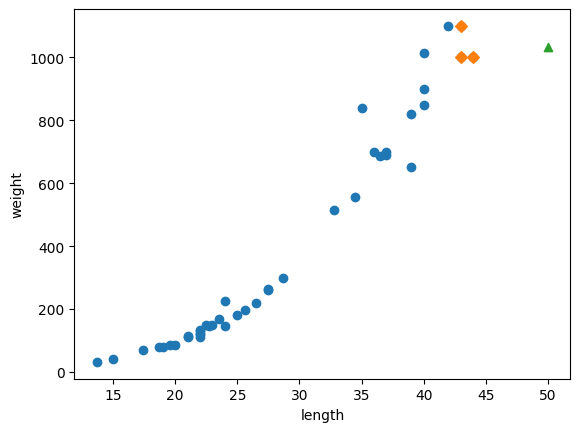

In [7]:
distances, indexes = knr.kneighbors(np.array([[50]]))
print(indexes)
print(indexes[0])

for length, weight in zip(train_input[indexes[0]], train_target[indexes[0]]):
    print(f"길이: {length}")
    print(f"길이: {length[0]}, 무게: {weight}")

# 훈련 세트 산점도
plt.scatter(train_input, train_target)

# 이웃 샘픒 산점도
plt.scatter(train_input[indexes], train_target[indexes], marker='D')

# 50cm 농어 데이터
plt.scatter(50, knr.predict(np.array([[50]])), marker='^')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

- 현재 훈련 세트에서 가장 큰 농어는 44cm입니다.
- 새로운 데이터 예측: 모델에 50cm나 100cm처럼 학습 데이터의 범위를 벗어나는 아주 큰 농어가 들어와도, 모델은 가장 가까운 거리에 있는 데이터(이미 학습된 43~44cm 농어들)를 찾아냅니다.

In [8]:
print(np.mean(train_target[indexes]))

1033.3333333333333


In [9]:
print(knr.predict(np.array([[100]])))

[1033.33333333]


### 문제점 발견 : 훈련 세트의 범위를 벗어나면 엉뚱한 값을 예측할 수 있습니다.

길이가 100 센티미터인 농어도 50 센티미터와 마찬가지로 1033.333333333333 값으로 예측합니다.

길이가 50 센티미터나 100 센티미터나 최근접 이웃이 동일해서 무게 값이 같습니다.

 ---

## 선형 회귀 (Linear Regression)

- 선형 회귀는 널리 사용되는 대표적인 회귀 알고리즘

- 특성이 하나인 경우 어떤 직선을 학습하는 알고리즘

- 어떤 직선이 농어 데이터를 가장 잘 표현하고 있을까요?

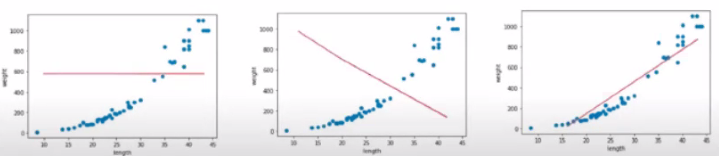

- 첫 번째는 모든 농어의 무게를 하나로 예측
- 두 번째는 길이가 작은 농어의 무게가 높고 큰 농어의 무게가 낮아요. 예측을 반대로 하고 있습니다.
- 세 번째는 농어의 길이가 늘어나면 무게도 늘어납니다.

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lr = LinearRegression()

lr.fit(train_input, train_target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
print(lr.predict(np.array([[50]])))

[1241.83860323]


In [13]:
# coef: 기울기
# intercept : 절편
print(lr.coef_, lr.intercept_)

[39.01714496] -709.0186449535474


coef_ 와 intercept_ 를 머신 러닝 알고리즘이 찾은 값이라는 의미로 **모델 파라미터**라고 합니다.

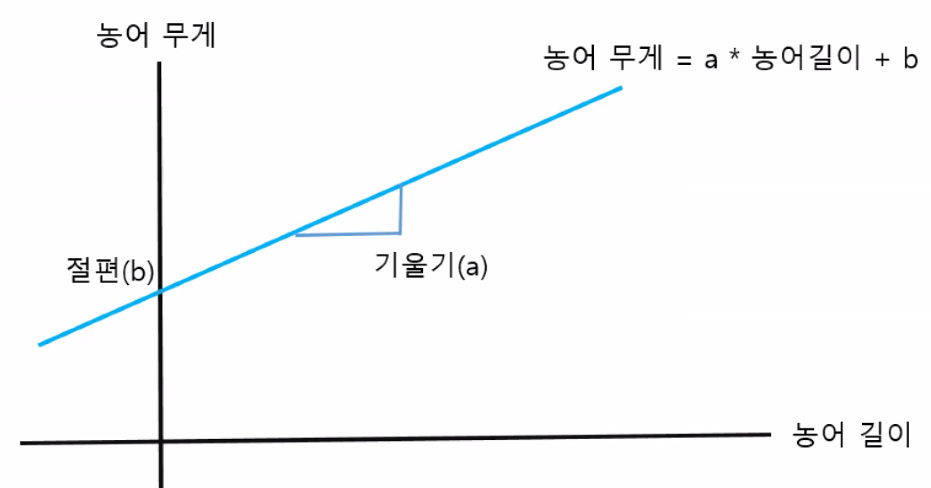


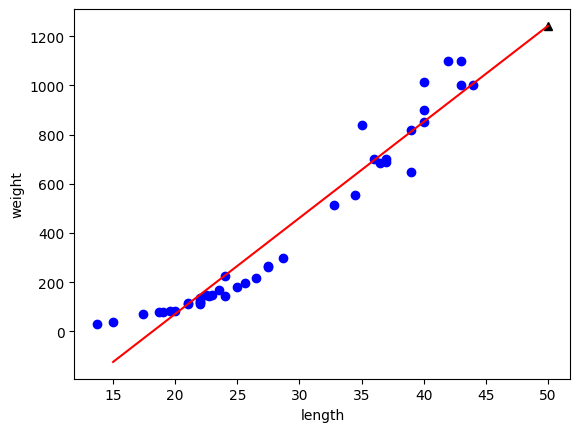

In [14]:
pred = lr.predict(np.array([[50]]))

plt.scatter(train_input, train_target, c='b')
plt.plot(50, pred, marker='^', c='black')

x = np.linspace(15, 50)
y = lr.coef_ * x + lr.intercept_
plt.plot(x, y, c='red')

plt.plot
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [15]:
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.9398463339976041
0.824750312331356


훈련 세트에 대한 결정계수 값이 이전의 k-최근점 이웃 결정계수값 보다 낮아요.

이럴 경우 과소 적합으로 판단합니다.

그런데 두 개의 수치만 보면 과대 적합으로 볼 수 있어 여러 가지 상황을 고려 해서 판단해야 합니다.

그래프에서의 문제점은 **농어의 무게가 음수**가 나올 수 있다는 것입니다.

해결법: 다항회귀(Polynomial Regression)는 선형회귀의 확장으로, 데이터가 직선으로 설명되지 않을 때 사용하는 회귀 기법입니다.

---

## 다항 회귀(Polynomial regression)

**용어 정리**:
- **항 (Term)**: 식을 구성하는 최소 단위의 '덩어리'입니다.
    - 예) $y = 3x^2 + 2x + 5$ 일 때  
    $3x^2$(2차항)  
    $2x$(1차항)  
    $5$(상수항)가 각각의 항입니다.
- **차수 (Degree)**: 항 안에 포함된 변수가 곱해진 횟수입니다.
    - $x^2$은 2차, $x$는 1차

---

1. 다항 회귀란?
    - 다항 회귀는 입력 변수 $x$의 거듭제곱 항을 사용하여 곡선 형태의 관계를 모델링 하는 회귀 방법입니다.
    - 예를 들어, 2차 다항 회귀는 다음과 같은 형태를 가집니다.

    $y = ax^2 + bx + c$

    - 그래프는 직선이 아닌 곡선으로 나타납니다.

2. 그래프는 곡선인데 왜 선형 회귀인가?
    - 여기서 $x^2$을 새로운 변수인 $X_1$으로, $x$를 $X_2$로 치환해 보겠습니다.

        $y = a \cdot X_1 + b \cdot X_2 + c$


        - 이렇게 놓고 보면, 타깃($y$)은 각 항에 계수($a, b$)를 곱해서 단순히 더한 형태가 됩니다.
        - 컴퓨터 입장에서는 그냥 '값 1'과 '값 2'를 받아서 가중치를 곱해 더하는 선형적인 계산을 수행할 뿐입니다.
        - $x^2$이라는 항이 들어가서 "비선형"처럼 보일 수 있지만, 계수($a, b$)와 타깃($y$)의 관계가 선형이기 때문에 여전히 선형 회귀의 범주에 포함됩니다.
        - 단순히 $x^2$이라는 새로운 특성(Feature)을 하나 추가한 것으로 간주하기 때문입니다.

- ### 최적의 곡선 찾기

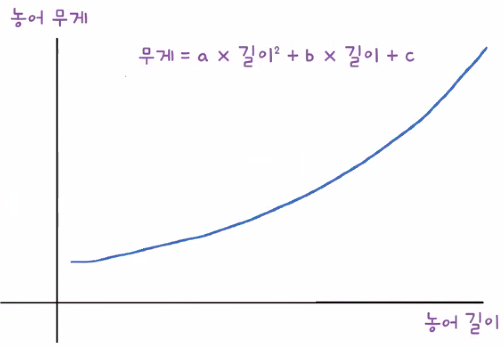

In [16]:
train_poly = np.column_stack((train_input ** 2, train_input))
test_poly = np.column_stack((test_input ** 2, test_input))

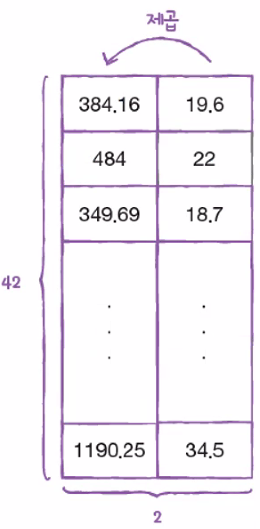

In [17]:
print(train_poly.shape, test_poly.shape)
print(train_poly)

(42, 2) (14, 2)
[[ 384.16   19.6 ]
 [ 484.     22.  ]
 [ 349.69   18.7 ]
 [ 302.76   17.4 ]
 [1296.     36.  ]
 [ 625.     25.  ]
 [1600.     40.  ]
 [1521.     39.  ]
 [1849.     43.  ]
 [ 484.     22.  ]
 [ 400.     20.  ]
 [ 484.     22.  ]
 [ 576.     24.  ]
 [ 756.25   27.5 ]
 [1849.     43.  ]
 [1600.     40.  ]
 [ 576.     24.  ]
 [ 441.     21.  ]
 [ 756.25   27.5 ]
 [1600.     40.  ]
 [1075.84   32.8 ]
 [ 702.25   26.5 ]
 [1332.25   36.5 ]
 [ 187.69   13.7 ]
 [ 515.29   22.7 ]
 [ 225.     15.  ]
 [1369.     37.  ]
 [1225.     35.  ]
 [ 823.69   28.7 ]
 [ 552.25   23.5 ]
 [1521.     39.  ]
 [ 441.     21.  ]
 [ 529.     23.  ]
 [ 484.     22.  ]
 [1936.     44.  ]
 [ 506.25   22.5 ]
 [ 361.     19.  ]
 [1369.     37.  ]
 [ 484.     22.  ]
 [ 655.36   25.6 ]
 [1764.     42.  ]
 [1190.25   34.5 ]]


In [18]:
lr = LinearRegression()

lr.fit(train_poly, train_target)

print(lr.coef_, lr.intercept_)

[  1.01433211 -21.55792498] 116.0502107827827


In [19]:
a, b = lr.coef_
c = lr.intercept_

print("학습된 다항 회귀식")
print(f"y = {a:.3f}x² + {b:.3f}x + {c:.3f}")

학습된 다항 회귀식
y = 1.014x² + -21.558x + 116.050


 ---
## 예측

길이가 50인 경우
- lr.fit(train_poly, train_target)에서 사용한 train_poly는 (42, 2) 형태이며, 각 샘플이 2개의 특성(x², x)을 가집니다.
- 따라서 predict()에서도 샘플 개수는 달라도 되지만, 특성의 개수는 반드시 동일하게 2개여야 합니다.

In [31]:
print(lr.predict(np.array([[50**2, 50]])))

[1573.98423528]


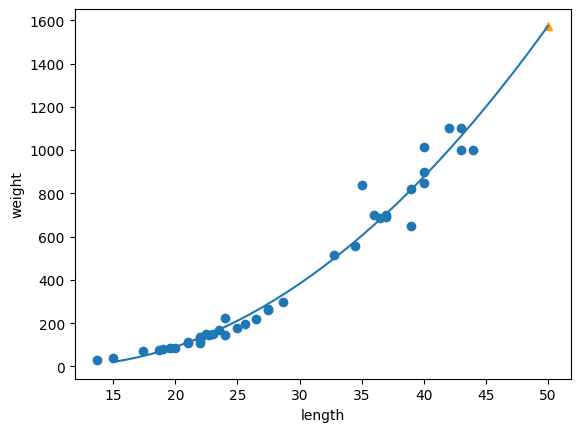

In [44]:
x = np.arange(15, 51)

plt.scatter(train_poly[:, 1], train_target)
plt.plot(50, lr.predict(np.array([[50**2, 50]])), marker='^', c='orange')
plt.plot(x, a*x**2 + b*x + lr.intercept_)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

 ---
### 단순 선형 회귀 모델보다 훨씬 나은 그래프가 그려졌습니다.

훈련 세트의 경향을 잘 따르고 음수의 무게가 나오는 일이 없습니다.

In [45]:
print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9706807451768623
0.9775935108325122


단순 선형 회귀

0.9398463339976041, 0.824750312331356

다항 선형 회귀

0.9706807451768623, 0.9775935108325122

훈련 세트와 테스트 세트의 점수가 크게 높아졌지만 테스트 세트의 점수가 조금 더 높습니다. 과소적합이 아직 남아있습니다.

해결) 조금 더 복잡한 모델을 만들어 이 문제를 해결해 보도록 하겠습니다.

---

### 정리

k 근접 알고리즘 단점은 훈련 세트 범위 밖에 있는 데이터는 잘 예측할 수 없습니다.

⇒ 해결 방법으로 선형 회귀 알고리즘 사용 (특성 하나로 간단한 모델로 만들어 봤습니다.)

문제점: 음수의 무게가 구해집니다. 이것을 해결하기 위해 2차원 그래프로 만들었습니다.

⇒ 다항 회귀로 부드러운 곡선으로 만들었습니다. (과소적합 문제 발생)